In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


# Change this value for another district
TARGET_DISTRICT = "NASHIK"


# 1) Load Excel file
file_path = "MEMSrepo.xlsx"
raw = pd.read_excel(file_path, header=None)

# Use row 1 as header, then remove the first two rows
df = raw.copy()
df.columns = df.iloc[1]
df = df.iloc[2:].reset_index(drop=True)


# 2) Clean column names: removes spaces and line breaks from column names]
df.columns = (
    df.columns.astype(str)
    .str.strip()
    .str.replace("\n", " ", regex=False)
    .str.replace(r"\s+", " ", regex=True)
)

print("Cleaned column names:")
print(df.columns.tolist())


# 3) Remove fully empty rows and duplicate rows
df = df.dropna(how="all").drop_duplicates().copy()


# 4) Clean important text columns
# We clean only if the column exists
text_cols = [
    "Call Type", "Ambulance Type", "Base Location", "Ambulance District",
    "Gender", "Incident District", "LOC", "ERCP Advice",
    "Provider Impression", "Receiving Hospital District",
    "Remark", "Patinent Availability status", "Patient Availability status"
]

for col in text_cols:
    if col in df.columns:
        df[col] = df[col].astype(str).str.strip()


# 5) Convert date column

if "Date" in df.columns:
    df["Date"] = pd.to_datetime(df["Date"], errors="coerce")
else:
    raise KeyError("Column 'Date' not found. Please check printed column names.")

# =========================================================
# 6) Convert time columns into timedelta
# This helps us safely add them to the Date column
# =========================================================
time_cols = [
    "Call Receiving Time", "Disconnected Time", "Start From Base",
    "At Scene", "From Scene", "At Hospital", "Handover Time", "Back To Base"
]

for col in time_cols:
    if col in df.columns:
        df[col] = pd.to_timedelta(df[col].astype(str), errors="coerce")

# =========================================================
# 7) Build full datetime columns
# Each event time = Date + that time column
# =========================================================
event_map = {
    "incident_time": "Call Receiving Time",
    "disconnect_time": "Disconnected Time",
    "dispatch_time": "Start From Base",
    "scene_time": "At Scene",
    "from_scene_time": "From Scene",
    "hospital_time": "At Hospital",
    "handover_time": "Handover Time",
    "return_time": "Back To Base"
}

for new_col, old_col in event_map.items():
    if old_col in df.columns:
        df[new_col] = df["Date"] + df[old_col]
    else:
        df[new_col] = pd.NaT

# =========================================================
# 8) Fix midnight crossing
# If a later event looks earlier than the previous event,
# we add one day
# =========================================================
event_order = [
    "incident_time", "disconnect_time", "dispatch_time", "scene_time",
    "from_scene_time", "hospital_time", "handover_time", "return_time"
]

for i in range(1, len(event_order)):
    prev_col = event_order[i - 1]
    curr_col = event_order[i]
    mask = df[curr_col].notna() & df[prev_col].notna() & (df[curr_col] < df[prev_col])
    df.loc[mask, curr_col] = df.loc[mask, curr_col] + pd.Timedelta(days=1)

# =========================================================
# 9) Filter chosen district
# =========================================================
if "Incident District" not in df.columns:
    raise KeyError("Column 'Incident District' not found. Please check printed column names.")

district_df = df[df["Incident District"].str.upper() == TARGET_DISTRICT.upper()].copy()

# =========================================================
# 10) Create zone column using Base Location
# =========================================================
if "Base Location" in district_df.columns:
    district_df["zone"] = district_df["Base Location"].astype(str).str.upper().str.strip()
else:
    raise KeyError("Column 'Base Location' not found.")

# =========================================================
# 11) Create time-based features
# =========================================================
district_df["hour"] = district_df["incident_time"].dt.hour
district_df["day_of_week"] = district_df["incident_time"].dt.day_name()

# =========================================================
# 12) Create severity using simple rules
# =========================================================
def get_severity(row):
    loc = str(row.get("LOC", "")).lower()
    ercp = str(row.get("ERCP Advice", "")).lower()
    imp = str(row.get("Provider Impression", "")).lower()

    high_words = ["unconscious", "unresponsive", "seizure", "resp", "head injury",
                  "poison", "cardiac", "chest pain", "trauma"]
    med_words = ["injury", "weakness", "fever", "abdominal", "pain", "fracture"]

    if "yes" in ercp or "unconscious" in loc or "unresponsive" in loc:
        return "HIGH"
    if any(word in imp for word in high_words):
        return "HIGH"
    if any(word in imp for word in med_words):
        return "MEDIUM"
    return "LOW"

district_df["severity"] = district_df.apply(get_severity, axis=1)

# =========================================================
# 13) Create duration columns in minutes
# =========================================================
def to_minutes(series):
    return series.dt.total_seconds() / 60

district_df["response_time_min"] = to_minutes(district_df["scene_time"] - district_df["dispatch_time"])
district_df["service_time_min"] = to_minutes(district_df["return_time"] - district_df["dispatch_time"])
district_df["total_case_time_min"] = to_minutes(district_df["return_time"] - district_df["incident_time"])

# Remove impossible values
for col in ["response_time_min", "service_time_min", "total_case_time_min"]:
    district_df.loc[(district_df[col] < 0) | (district_df[col] > 24 * 60), col] = np.nan

print(f"Total cleaned rows in {TARGET_DISTRICT}: {len(district_df)}")
print("\nTop zones:")
print(district_df["zone"].value_counts().head(10))

Cleaned column names:
['Sr.No', 'Date', 'Call Type', 'Ambulance Type', 'Base Location', 'Ambulance District', 'Age', 'Gender', 'Incident District', 'LOC', 'ERCP Advice', 'Provider Impression', 'Receiving Hospital District', 'Remark', 'Patinent Availability status', 'Call Receiving Time', 'Disconnected Time', 'Start From Base', 'At Scene', 'From Scene', 'At Hospital', 'Handover Time', 'Back To Base', 'Response Time']
Total cleaned rows in NASHIK: 532

Top zones:
zone
TRIMBAK RURAL HOSPITAL                     30
GHOTI HIGHWAY                              28
MALEGAON PHATA-HIGHWAY LOCATION HIGHWAY    25
HARSUL RURAL HOSPITAL                      22
SWAMI SAMARTH NMC HOSPITAL, MORWADI        20
DABHADI RURAL HOSPITAL                     19
KALWAN SUB DISTRICT HOSPITAL               18
MALEGAON GENERAL HOSPITAL                  18
PETH RURAL HOSPITAL                        16
KANASHI PRIMARY HEALTH CENTER              16
Name: count, dtype: int64


In [13]:
# =========================================================
# 1) Hour distribution
# This gives probability of incidents by hour
# =========================================================
hour_dist = district_df["hour"].value_counts().sort_index()
hour_prob = (hour_dist / hour_dist.sum()).rename("probability")

# =========================================================
# 2) Severity distribution
# =========================================================
severity_dist = district_df["severity"].value_counts()
severity_prob = (severity_dist / severity_dist.sum()).rename("probability")

# =========================================================
# 3) Inter-arrival time
# Time difference between consecutive incidents
# =========================================================
district_df = district_df.sort_values("incident_time").copy()
district_df["inter_arrival_min"] = district_df["incident_time"].diff().dt.total_seconds() / 60
district_df.loc[
    (district_df["inter_arrival_min"] < 0) | (district_df["inter_arrival_min"] > 24 * 60),
    "inter_arrival_min"
] = np.nan

# =========================================================
# 4) Zone-level hotspot summary
# =========================================================
zone_stats = district_df.groupby("zone").agg(
    incident_count=("zone", "size"),
    severe_count=("severity", lambda x: (x == "HIGH").sum()),
    avg_response_time=("response_time_min", "mean"),
    avg_service_time=("service_time_min", "mean")
).reset_index()

# Find peak-hour demand for each zone
zone_hour = district_df.groupby(["zone", "hour"]).size().reset_index(name="count")
peak_hour = zone_hour.groupby("zone")["count"].max().reset_index(name="peak_hour_demand")

zone_stats = zone_stats.merge(peak_hour, on="zone", how="left")

# Fill missing numeric values
num_cols = ["incident_count", "severe_count", "avg_response_time", "avg_service_time", "peak_hour_demand"]
zone_stats[num_cols] = zone_stats[num_cols].fillna(0)

# =========================================================
# 5) Normalize values before computing hotspot score
# =========================================================
for col in ["incident_count", "severe_count", "avg_response_time", "peak_hour_demand"]:
    max_val = zone_stats[col].max()
    zone_stats[f"{col}_norm"] = zone_stats[col] / max_val if max_val > 0 else 0

# =========================================================
# 6) Final hotspot score
# You can change weights later if needed
# =========================================================
zone_stats["hotspot_score"] = (
    0.4 * zone_stats["incident_count_norm"] +
    0.3 * zone_stats["severe_count_norm"] +
    0.2 * zone_stats["avg_response_time_norm"] +
    0.1 * zone_stats["peak_hour_demand_norm"]
)

hotspots = zone_stats.sort_values("hotspot_score", ascending=False).reset_index(drop=True)

# =========================================================
# 7) Add simple hotspot type labels from zone name
# =========================================================
def hotspot_type(zone_name):
    z = str(zone_name).lower()
    if "highway" in z or "phata" in z:
        return "HIGHWAY"
    elif "rural" in z or "phc" in z or "sub district hospital" in z:
        return "RURAL_HEALTH_BELT"
    elif "city" in z or "nagar" in z:
        return "RESIDENTIAL_OR_TOWN"
    elif "station" in z or "bus stand" in z:
        return "TRANSPORT_CORRIDOR"
    else:
        return "OTHER"

hotspots["hotspot_type"] = hotspots["zone"].apply(hotspot_type)

# =========================================================
# 8) Print important results
# =========================================================
print(f"Top 10 hotspots in {TARGET_DISTRICT}")
display(hotspots.head(10))

print(f"\nHourly demand distribution for {TARGET_DISTRICT}")
display(hour_prob.reset_index().rename(columns={"index": "hour"}))

print(f"\nSeverity distribution for {TARGET_DISTRICT}")
display(severity_prob.reset_index().rename(columns={"index": "severity"}))

print(f"\nInter-arrival summary for {TARGET_DISTRICT} (minutes)")
display(district_df["inter_arrival_min"].describe())

print(f"\nService time summary for {TARGET_DISTRICT} (minutes)")
display(district_df["service_time_min"].describe())

Top 10 hotspots in NASHIK


,zone,incident_count,severe_count,avg_response_time,avg_service_time,peak_hour_demand,incident_count_norm,severe_count_norm,avg_response_time_norm,peak_hour_demand_norm,hotspot_score,hotspot_type
0,GHOTI HIGHWAY,28,9,20.658929,146.926786,7,0.933333,0.818182,0.535205,1.000000,0.825829,HIGHWAY
1,"SWAMI SAMARTH NMC HOSPITAL, MORWADI",20,11,34.275833,123.856667,3,0.666667,1.000000,0.887975,0.428571,0.787119,OTHER
2,MALEGAON PHATA-HIGHWAY LOCATION HIGHWAY,25,7,23.970667,159.186806,4,0.833333,0.636364,0.621002,0.571429,0.705586,HIGHWAY
3,HARSUL RURAL HOSPITAL,22,8,15.090909,196.868182,5,0.733333,0.727273,0.390956,0.714286,0.661135,RURAL_HEALTH_BELT
4,TRIMBAK RURAL HOSPITAL,30,1,26.633333,145.225556,5,1.000000,0.090909,0.689983,0.714286,0.636698,RURAL_HEALTH_BELT
5,KALWAN SUB DISTRICT HOSPITAL,18,7,13.222222,169.444444,4,0.600000,0.636364,0.342545,0.571429,0.556561,RURAL_HEALTH_BELT
6,CHANDWAD SUB DISTRICT HOSPITAL,14,9,12.225000,97.658333,3,0.466667,0.818182,0.316710,0.428571,0.538320,RURAL_HEALTH_BELT
7,MALEGAON GENERAL HOSPITAL,18,6,16.738889,173.717593,3,0.600000,0.545455,0.433650,0.428571,0.533224,OTHER
8,DABHADI RURAL HOSPITAL,19,3,24.052632,155.368421,3,0.633333,0.272727,0.623125,0.428571,0.502634,RURAL_HEALTH_BELT
9,KANASHI PRIMARY HEALTH CENTER,16,4,26.812500,128.168750,2,0.533333,0.363636,0.694624,0.285714,0.489921,OTHER



Hourly demand distribution for NASHIK


,hour,probability
0,0,0.030075
1,1,0.018797
2,2,0.022556
3,3,0.020677
4,4,0.016917
5,5,0.026316
6,6,0.024436
7,7,0.031955
8,8,0.035714
9,9,0.058271



Severity distribution for NASHIK


,severity,probability
0,LOW,0.629699
1,HIGH,0.285714
2,MEDIUM,0.084586



Inter-arrival summary for NASHIK (minutes)


count    531.000000
mean      18.959196
std       20.784591
min        0.000000
25%        4.725000
50%       12.016667
75%       26.025000
max      137.000000
Name: inter_arrival_min, dtype: float64


Service time summary for NASHIK (minutes)


count    531.000000
mean     149.196830
std       86.728137
min        1.000000
25%       79.000000
50%      137.000000
75%      197.500000
max      495.000000
Name: service_time_min, dtype: float64

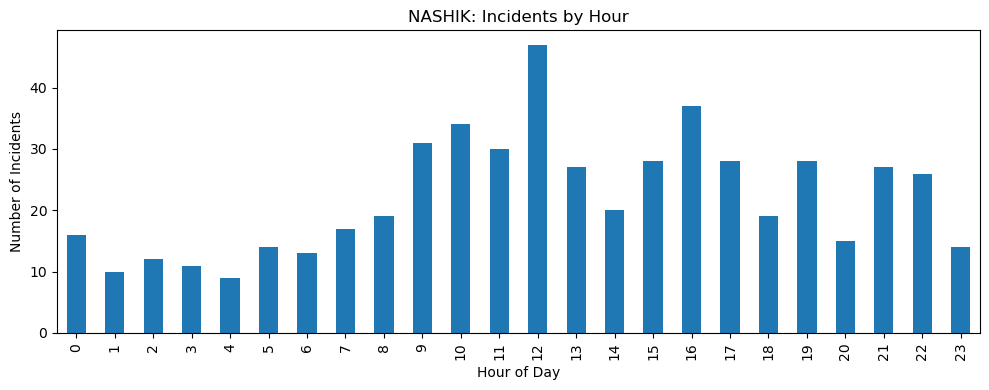

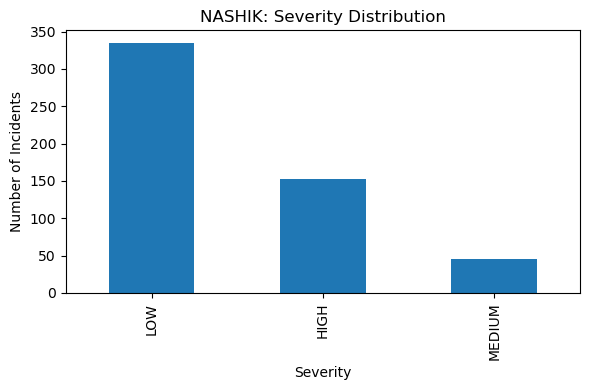

<Figure size 1000x500 with 0 Axes>

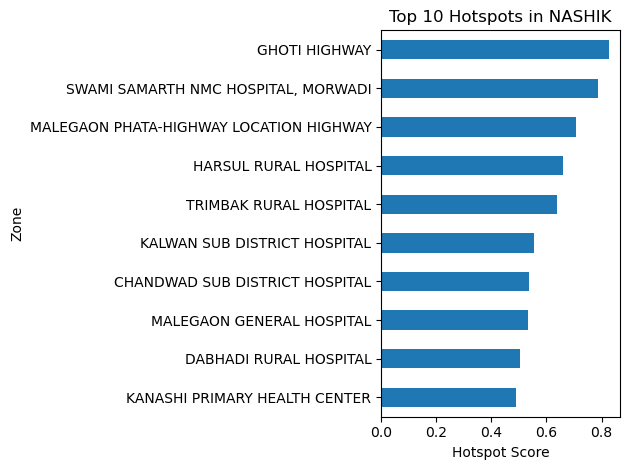

Stage 1 complete.
Saved files:
- nashik_clean_stage1.csv
- nashik_hotspots_stage1.csv
- nashik_hour_prob_stage1.csv
- nashik_severity_prob_stage1.csv
- nashik_time_distributions_stage1.csv


In [16]:
# =========================================================
# 1) Plot incidents by hour
# =========================================================
plt.figure(figsize=(10, 4))
hour_dist.plot(kind="bar")
plt.title(f"{TARGET_DISTRICT}: Incidents by Hour")
plt.xlabel("Hour of Day")
plt.ylabel("Number of Incidents")
plt.tight_layout()
plt.show()

# =========================================================
# 2) Plot severity distribution
# =========================================================
plt.figure(figsize=(6, 4))
severity_dist.plot(kind="bar")
plt.title(f"{TARGET_DISTRICT}: Severity Distribution")
plt.xlabel("Severity")
plt.ylabel("Number of Incidents")
plt.tight_layout()
plt.show()

# =========================================================
# 3) Plot top hotspot zones
# =========================================================
plt.figure(figsize=(10, 5))
hotspots.head(10).sort_values("hotspot_score").plot(
    x="zone", y="hotspot_score", kind="barh", legend=False
)
plt.title(f"Top 10 Hotspots in {TARGET_DISTRICT}")
plt.xlabel("Hotspot Score")
plt.ylabel("Zone")
plt.tight_layout()
plt.show()

# =========================================================
# 4) Save outputs
# Files are named using district variable
# =========================================================
district_name_safe = TARGET_DISTRICT.lower().replace(" ", "_")

district_df.to_csv(f"{district_name_safe}_clean_stage1.csv", index=False)
hotspots.to_csv(f"{district_name_safe}_hotspots_stage1.csv", index=False)
hour_prob.to_csv(f"{district_name_safe}_hour_prob_stage1.csv")
severity_prob.to_csv(f"{district_name_safe}_severity_prob_stage1.csv")

district_df[[
    "incident_time", "inter_arrival_min", "response_time_min", "service_time_min", "total_case_time_min"
]].to_csv(f"{district_name_safe}_time_distributions_stage1.csv", index=False)

print("Stage 1 complete.")
print("Saved files:")
print(f"- {district_name_safe}_clean_stage1.csv")
print(f"- {district_name_safe}_hotspots_stage1.csv")
print(f"- {district_name_safe}_hour_prob_stage1.csv")
print(f"- {district_name_safe}_severity_prob_stage1.csv")
print(f"- {district_name_safe}_time_distributions_stage1.csv")

Generated 592 synthetic incidents
Start date used: 2026-04-19


,event_id,incident_time,date,hour,day_of_week,zone,zone_type,severity,hospital_specialty_requirement,service_duration_min,exceptional_event
0,NAS_000001,2026-04-19 00:05:30,2026-04-19,0,Sunday,BORGAON PHC,RURAL_BELT,LOW,Gynaecology,238.0,NONE
1,NAS_000002,2026-04-19 00:07:46,2026-04-19,0,Sunday,PIMPALGAON PRIMARY HEALTH CENTER,RURAL_BELT,LOW,CARDIOLOGY,205.0,NONE
2,NAS_000003,2026-04-19 00:20:38,2026-04-19,0,Sunday,UMRALE BUDRUK PRIMARY HEALTH CENTER,OTHER,HIGH,CARDIOLOGY,120.0,NONE
3,NAS_000004,2026-04-19 00:24:42,2026-04-19,0,Sunday,GHOTI HIGHWAY,HIGHWAY,LOW,Pediatrics,210.0,NONE
4,NAS_000005,2026-04-19 01:10:46,2026-04-19,1,Sunday,HARSUL RURAL HOSPITAL,HOSPITAL_BELT,HIGH,Pediatrics,332.0,NONE


Synthetic severity distribution:


severity
LOW       0.613176
HIGH      0.285473
MEDIUM    0.101351
Name: probability, dtype: float64


Synthetic hospital specialty distribution:


hospital_specialty_requirement
Gynaecology     0.423986
CRITICAL        0.143581
General         0.111486
Pediatrics      0.104730
CARDIOLOGY      0.074324
Medicine        0.032095
Pulmonology     0.030405
Neurosurgery    0.028716
Neurology       0.025338
ORTHOPEDICS     0.011824
Polytrauma      0.008446
BURNS           0.005068
Name: probability, dtype: float64


Synthetic zone distribution:


zone
SWAMI SAMARTH NMC HOSPITAL, MORWADI        0.050676
KALWAN SUB DISTRICT HOSPITAL               0.047297
GHOTI HIGHWAY                              0.040541
PETH RURAL HOSPITAL                        0.038851
MALEGAON PHATA-HIGHWAY LOCATION HIGHWAY    0.038851
HARSUL RURAL HOSPITAL                      0.035473
MANMAD SUB DISTRICT HOSPITAL               0.032095
MALEGAON GENERAL HOSPITAL                  0.032095
TRIMBAK RURAL HOSPITAL                     0.032095
BYTCO NMC HOSPITAL, NASHIK ROAD            0.030405
Name: probability, dtype: float64


Synthetic exceptional event distribution:


exceptional_event
NONE                   0.937500
HIGHWAY_CRASH_BURST    0.023649
RAIN_DISRUPTION        0.021959
FESTIVAL_CROWDING      0.016892
Name: probability, dtype: float64

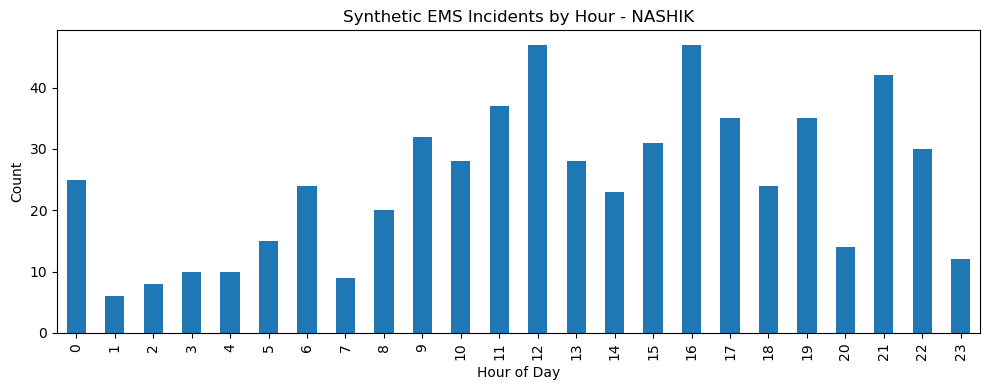

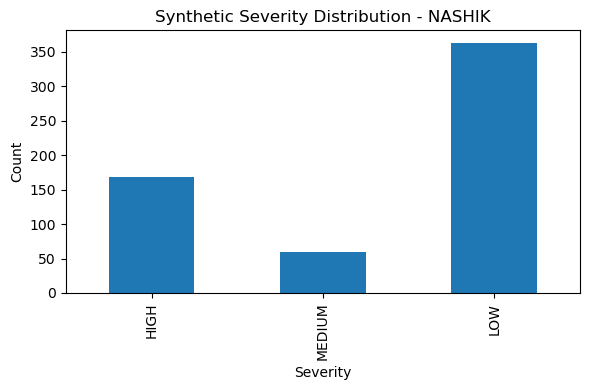

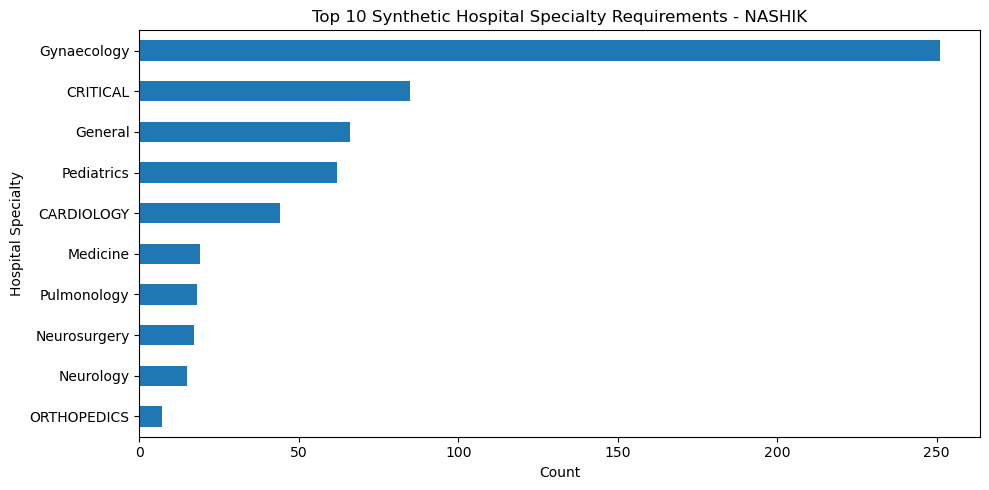

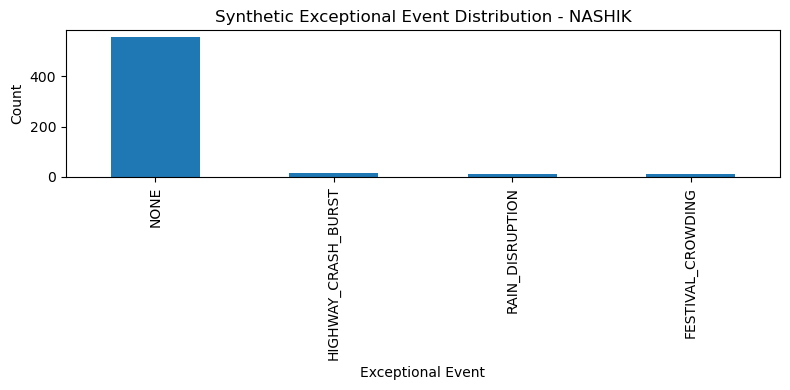

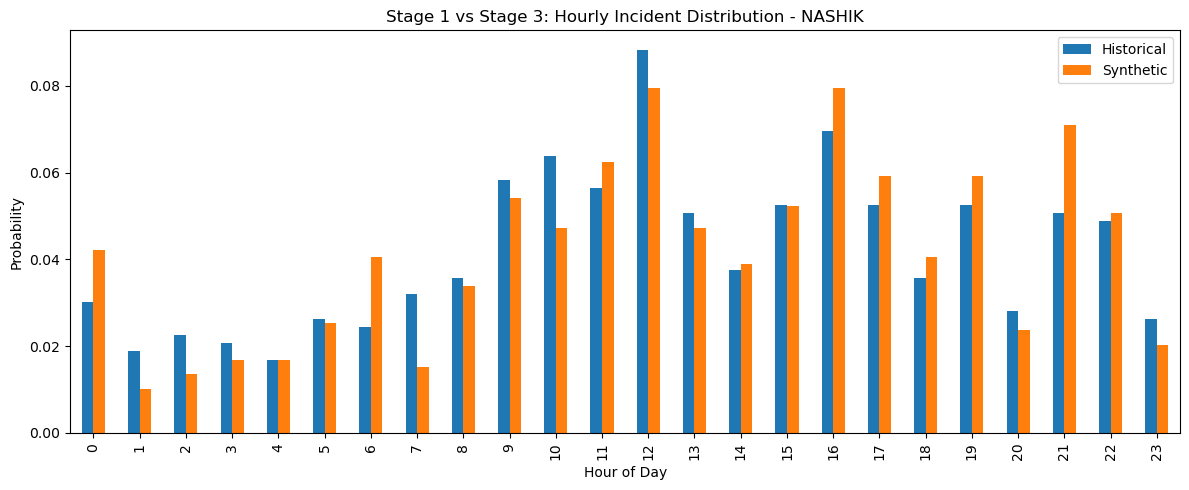

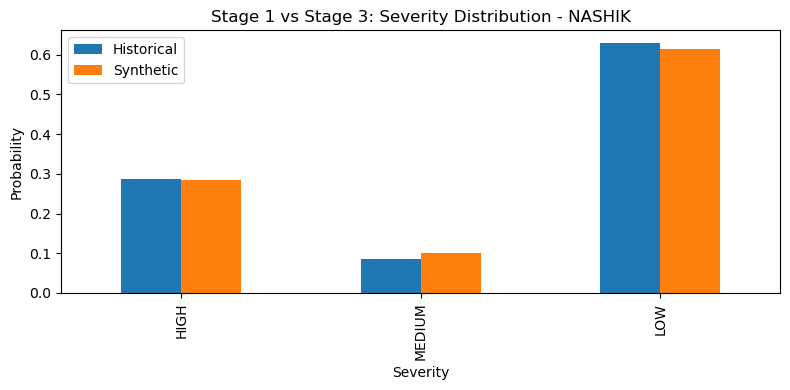

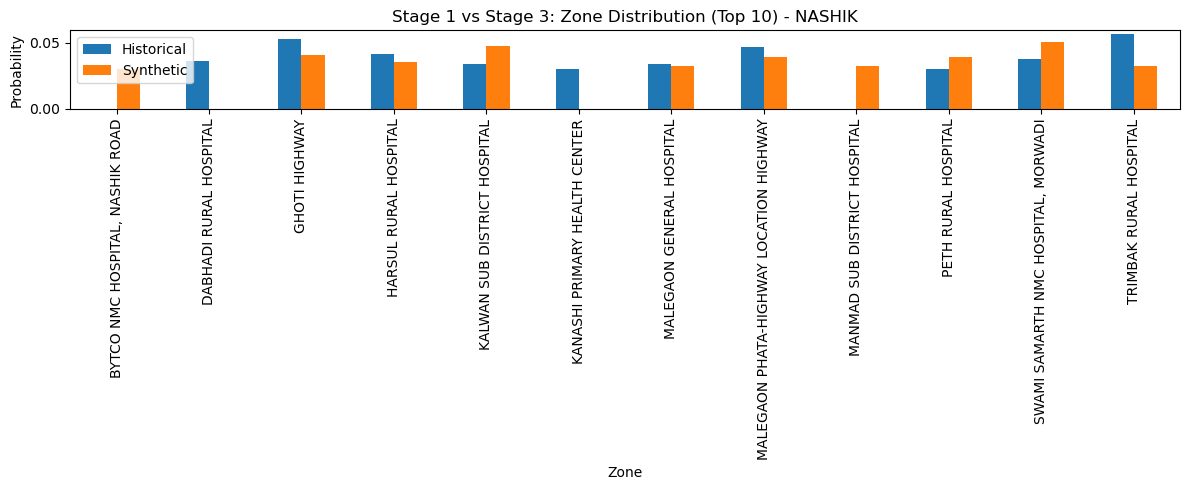

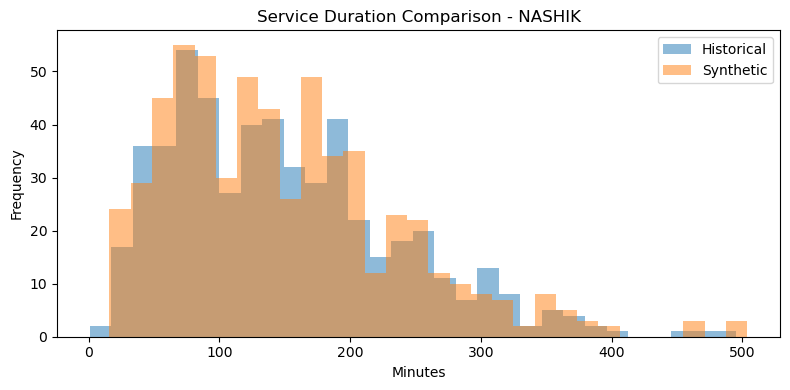

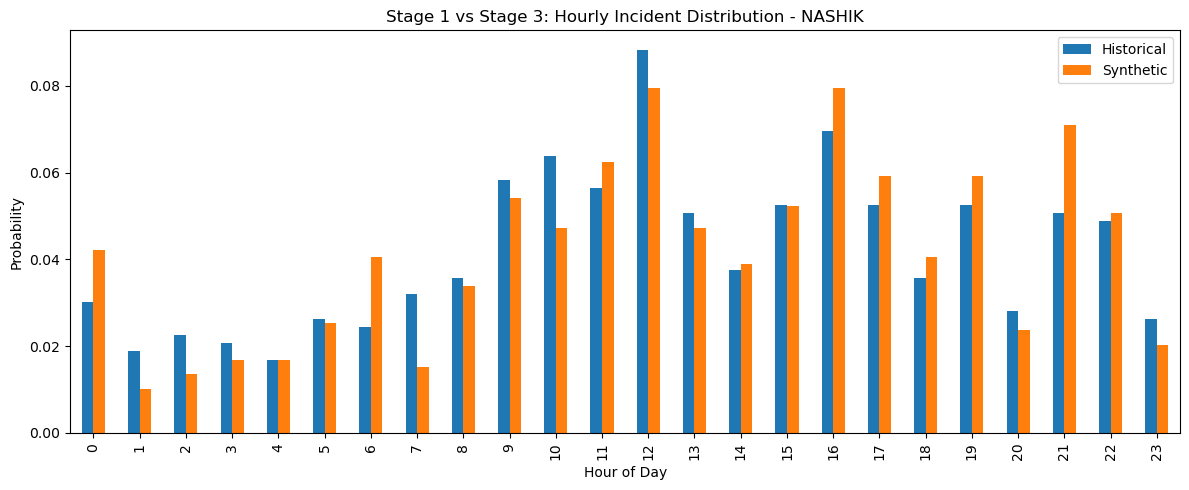

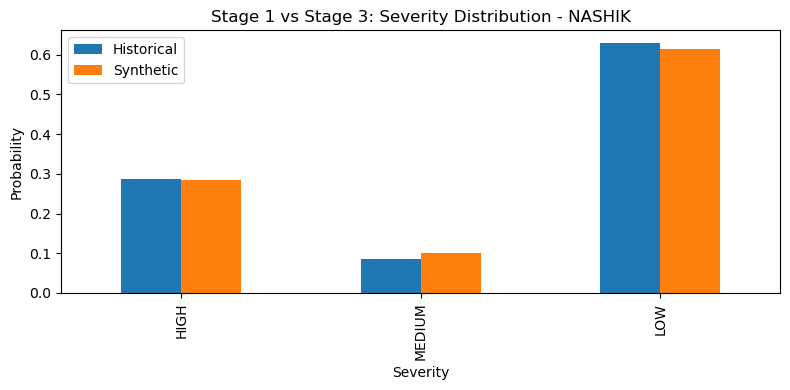

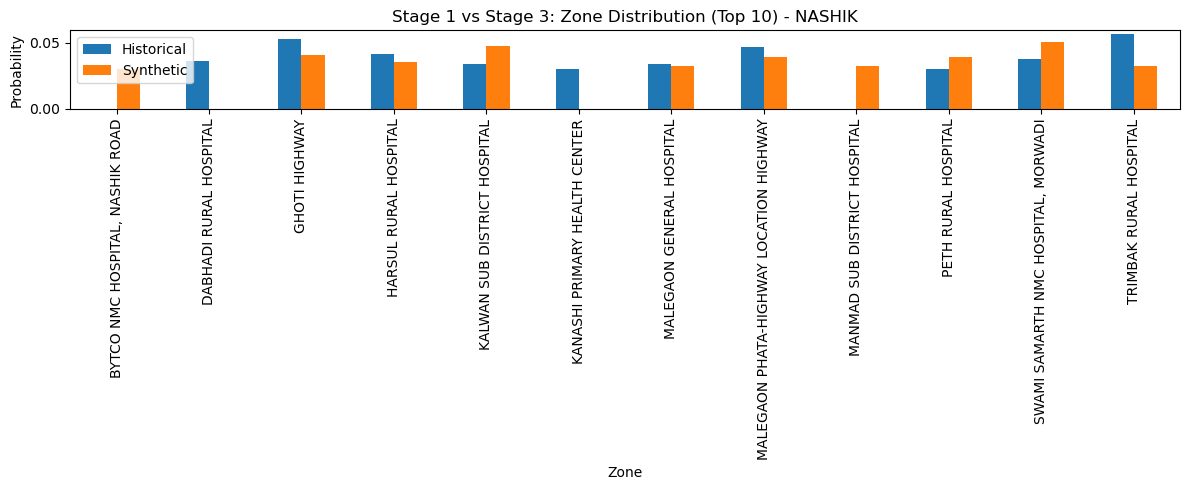

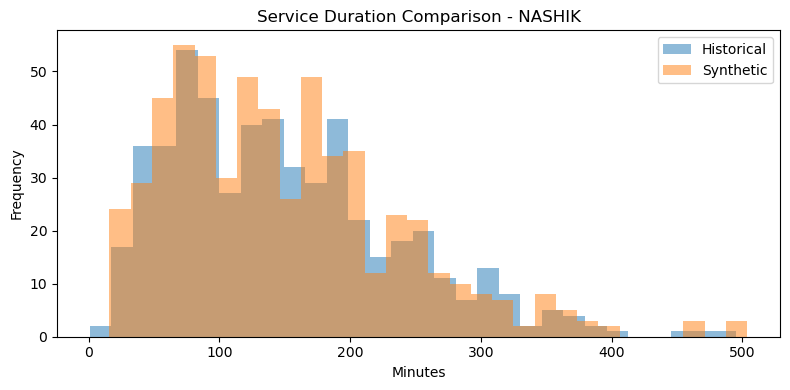

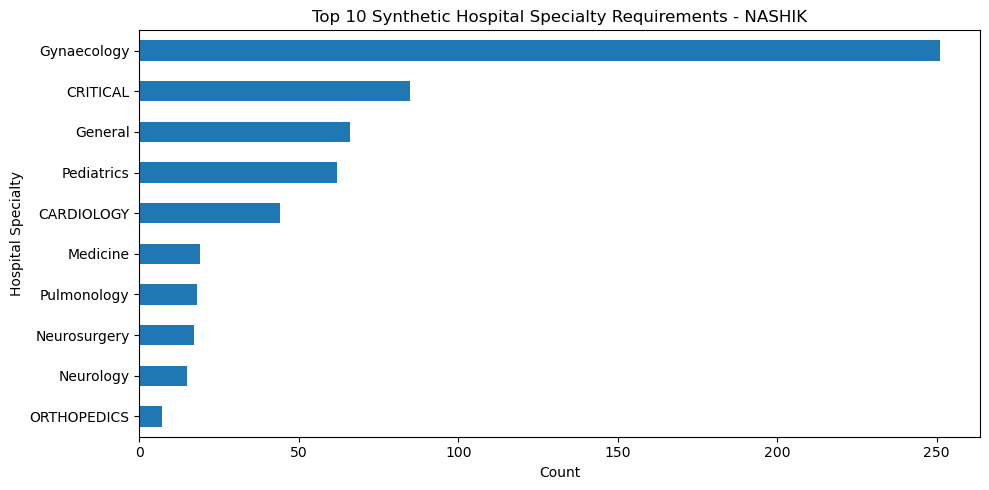

Saved synthetic data to: nashik_synthetic_stage3.csv
Saved figures in ./figures/


In [18]:
# =========================================================
# STAGE 3 — SYNTHETIC INCIDENT GENERATION
# Updated version:
# - start date = today's date
# - hour-wise Poisson arrivals
# - zone-based hotspot sampling
# - severity conditioned on zone type
# - hospital specialty requirement generated directly
# - service duration conditioned on severity
# - exceptional events kept
# - validation plots included
# =========================================================

import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# =========================================================
# USER SETTINGS
# =========================================================
TARGET_DISTRICT = "NASHIK"
SIM_DAYS = 7
START_DATE = pd.Timestamp.today().normalize()   # today's date
RANDOM_SEED = 42

np.random.seed(RANDOM_SEED)

# =========================================================
# REQUIRED INPUTS FROM STAGE 1
# Assumes these already exist:
#   district_df
#   hotspots
# =========================================================
hist_df = district_df.copy()
hist_df["date_only"] = hist_df["incident_time"].dt.date

# =========================================================
# EXACT HOSPITAL SPECIALTY CATEGORIES PROVIDED BY YOU
# =========================================================
HOSPITAL_CATEGORIES = [
    "CARDIOLOGY",
    "UROLOGY",
    "BURNS",
    "CRITICAL",
    "Neurology",
    "Neurosurgery",
    "Polytrauma",
    "Pulmonology",
    "Medicine",
    "General",
    "Pediatrics",
    "ORTHOPEDICS",
    "Gynaecology",
    "Nephrology",
    "CARDIOTHORACIC"
]

# =========================================================
# 1) HOUR-WISE POISSON ARRIVAL MODEL
# lambda(hour) = avg incidents in that hour per historical day
# =========================================================
num_hist_days = max(1, hist_df["date_only"].nunique())

hour_counts = hist_df["hour"].value_counts().sort_index()
hourly_lambda = pd.Series(0.0, index=range(24), dtype=float)
hourly_lambda.loc[hour_counts.index] = hour_counts.values / num_hist_days

# =========================================================
# 2) ZONE PROBABILITIES FROM HOTSPOT SCORE
# =========================================================
zone_prob_df = hotspots.copy()

if "hotspot_score" in zone_prob_df.columns:
    zone_prob_df["zone_weight"] = zone_prob_df["hotspot_score"].clip(lower=0)
else:
    zone_prob_df["zone_weight"] = zone_prob_df["incident_count"].clip(lower=0)

if zone_prob_df["zone_weight"].sum() == 0:
    zone_prob_df["zone_weight"] = 1.0

zone_prob_df["zone_prob"] = zone_prob_df["zone_weight"] / zone_prob_df["zone_weight"].sum()

# =========================================================
# 3) ZONE TYPE CLASSIFICATION
# =========================================================
def classify_zone_type(zone_name):
    z = str(zone_name).upper()

    if any(k in z for k in ["HIGHWAY", "EXPRESS", "NH", "ROAD", "BYPASS"]):
        return "HIGHWAY"
    elif any(k in z for k in ["HOSP", "MEDICAL", "CIVIL", "TRAUMA"]):
        return "HOSPITAL_BELT"
    elif any(k in z for k in ["BUS", "RAIL", "STATION", "JUNCTION", "DEPOT", "TRANSPORT"]):
        return "TRANSPORT_CORRIDOR"
    elif any(k in z for k in ["CITY", "NAGAR", "URBAN", "CENTRAL", "TOWN"]):
        return "URBAN_CORE"
    elif any(k in z for k in ["RURAL", "GAON", "VILLAGE", "TALUKA"]):
        return "RURAL_BELT"
    else:
        return "OTHER"

hist_df["zone_type"] = hist_df["zone"].apply(classify_zone_type)

# =========================================================
# 4) SEVERITY CONDITIONED ON ZONE TYPE
# P(severity | zone_type)
# =========================================================
severity_levels = ["HIGH", "MEDIUM", "LOW"]

severity_by_zone_type = {}
for zt in hist_df["zone_type"].dropna().unique():
    sub = hist_df.loc[hist_df["zone_type"] == zt, "severity"].dropna()
    probs = sub.value_counts(normalize=True).to_dict()

    sev_map = {sev: float(probs.get(sev, 0.0)) for sev in severity_levels}
    total = sum(sev_map.values())

    if total == 0:
        sev_map = {"HIGH": 0.20, "MEDIUM": 0.40, "LOW": 0.40}
    else:
        sev_map = {k: v / total for k, v in sev_map.items()}

    severity_by_zone_type[zt] = sev_map

global_sev = hist_df["severity"].dropna().value_counts(normalize=True).to_dict()
global_sev_full = {sev: float(global_sev.get(sev, 0.0)) for sev in severity_levels}
if sum(global_sev_full.values()) == 0:
    global_sev_full = {"HIGH": 0.20, "MEDIUM": 0.40, "LOW": 0.40}
else:
    s = sum(global_sev_full.values())
    global_sev_full = {k: v / s for k, v in global_sev_full.items()}

# =========================================================
# 5) SERVICE DURATION CONDITIONED ON SEVERITY
# =========================================================
service_time_by_severity = {}
for sev in severity_levels:
    vals = hist_df.loc[
        (hist_df["severity"] == sev) &
        (hist_df["service_time_min"].notna()) &
        (hist_df["service_time_min"] >= 5) &
        (hist_df["service_time_min"] <= 24 * 60),
        "service_time_min"
    ].astype(float).values

    if len(vals) == 0:
        if sev == "HIGH":
            vals = np.array([60, 75, 90, 120], dtype=float)
        elif sev == "MEDIUM":
            vals = np.array([40, 50, 60, 75], dtype=float)
        else:
            vals = np.array([20, 30, 40, 50], dtype=float)

    service_time_by_severity[sev] = vals

# =========================================================
# 6) DIRECT HOSPITAL SPECIALTY REQUIREMENT MAPPING
# FROM PROVIDER IMPRESSION -> YOUR EXACT HOSPITAL CATEGORIES
# =========================================================
def map_hospital_specialty(provider_impression, severity, age=None, gender=None):
    text = str(provider_impression).lower().strip()

    # Pediatrics first if age available and child-like
    if age is not None:
        try:
            if float(age) <= 14:
                return "Pediatrics"
        except:
            pass

    # Gynaecology
    if any(k in text for k in [
        "pregnan", "labor", "delivery", "bleeding pv", "gyn", "obstetric", "uterine", "female pain"
    ]):
        return "Gynaecology"

    # Cardiology / cardiothoracic
    if any(k in text for k in [
        "chest pain", "cardiac", "heart", "mi", "myocard", "angina", "palpitation"
    ]):
        return "CARDIOLOGY"

    if any(k in text for k in [
        "thoracic", "aortic", "post cabg", "bypass graft", "cardiothoracic"
    ]):
        return "CARDIOTHORACIC"

    # Neuro
    if any(k in text for k in [
        "stroke", "cva", "paralysis", "seizure", "convulsion", "neuro", "neurology"
    ]):
        return "Neurology"

    if any(k in text for k in [
        "head injury", "brain injury", "intracranial", "neurosurgery", "spine trauma", "spinal injury"
    ]):
        return "Neurosurgery"

    # Trauma / ortho / burns
    if any(k in text for k in [
        "polytrauma", "multiple injury", "rt a", "rta", "road traffic", "accident major trauma"
    ]):
        return "Polytrauma"

    if any(k in text for k in [
        "fracture", "ortho", "orthopedic", "dislocation", "limb injury", "bone injury"
    ]):
        return "ORTHOPEDICS"

    if any(k in text for k in [
        "burn", "flame", "scald", "electrical burn", "thermal injury"
    ]):
        return "BURNS"

    # Pulmonary
    if any(k in text for k in [
        "resp", "breath", "asthma", "copd", "wheeze", "pneumonia", "pulmonary", "oxygen"
    ]):
        return "Pulmonology"

    # Renal / uro
    if any(k in text for k in [
        "renal", "kidney", "dialysis", "nephro", "creatinine", "ckd"
    ]):
        return "Nephrology"

    if any(k in text for k in [
        "urine", "urology", "catheter", "retention", "hematuria", "stone", "prostate"
    ]):
        return "UROLOGY"

    # Severity-driven fallback
    if severity == "HIGH":
        return "CRITICAL"
    elif severity == "MEDIUM":
        return "Medicine"
    else:
        return "General"

# Build empirical specialty distribution by severity from historical data
# so Stage 3 directly samples one of your exact categories.
hist_df["hospital_specialty_requirement_hist"] = hist_df.apply(
    lambda row: map_hospital_specialty(
        provider_impression=row.get("Provider Impression", ""),
        severity=row.get("severity", "LOW"),
        age=row.get("Age", None),
        gender=row.get("Gender", None)
    ),
    axis=1
)

specialty_by_severity = {}
for sev in severity_levels:
    sub = hist_df.loc[hist_df["severity"] == sev, "hospital_specialty_requirement_hist"].dropna()

    if len(sub) == 0:
        if sev == "HIGH":
            spec_probs = {
                "CRITICAL": 0.30,
                "Polytrauma": 0.20,
                "CARDIOLOGY": 0.15,
                "Neurology": 0.15,
                "Neurosurgery": 0.10,
                "Pulmonology": 0.10
            }
        elif sev == "MEDIUM":
            spec_probs = {
                "Medicine": 0.35,
                "ORTHOPEDICS": 0.20,
                "CARDIOLOGY": 0.10,
                "Pulmonology": 0.10,
                "Nephrology": 0.10,
                "UROLOGY": 0.05,
                "Gynaecology": 0.10
            }
        else:
            spec_probs = {
                "General": 0.55,
                "Medicine": 0.20,
                "Pediatrics": 0.10,
                "UROLOGY": 0.05,
                "Gynaecology": 0.05,
                "ORTHOPEDICS": 0.05
            }
    else:
        probs = sub.value_counts(normalize=True).to_dict()
        spec_probs = {cat: float(probs.get(cat, 0.0)) for cat in HOSPITAL_CATEGORIES}
        total = sum(spec_probs.values())
        if total == 0:
            spec_probs = {"General": 1.0}
        else:
            spec_probs = {k: v / total for k, v in spec_probs.items() if v > 0}

    specialty_by_severity[sev] = spec_probs

# =========================================================
# 7) HELPER FUNCTIONS
# =========================================================
def weighted_choice(items, probs):
    probs = np.array(probs, dtype=float)
    probs = probs / probs.sum()
    return np.random.choice(items, p=probs)

def sample_zone():
    return weighted_choice(
        zone_prob_df["zone"].tolist(),
        zone_prob_df["zone_prob"].tolist()
    )

def sample_severity(zone_type):
    sev_dist = severity_by_zone_type.get(zone_type, global_sev_full)
    items = list(sev_dist.keys())
    probs = list(sev_dist.values())
    return weighted_choice(items, probs)

def sample_hospital_specialty(severity):
    spec_dist = specialty_by_severity.get(severity, {"General": 1.0})
    items = list(spec_dist.keys())
    probs = list(spec_dist.values())
    return weighted_choice(items, probs)

def sample_service_time(severity):
    vals = service_time_by_severity.get(severity, np.array([30, 45, 60], dtype=float))
    x = float(np.random.choice(vals))
    return max(5, round(x, 2))

def sample_exception(hour, zone_type):
    probs = {
        "NONE": 0.94,
        "HIGHWAY_CRASH_BURST": 0.02,
        "FESTIVAL_CROWDING": 0.02,
        "RAIN_DISRUPTION": 0.02
    }

    if zone_type == "HIGHWAY":
        probs["HIGHWAY_CRASH_BURST"] += 0.06
        probs["NONE"] -= 0.04

    if zone_type in ["URBAN_CORE", "TRANSPORT_CORRIDOR"] and 17 <= hour <= 22:
        probs["FESTIVAL_CROWDING"] += 0.05
        probs["NONE"] -= 0.03

    total = sum(probs.values())
    probs = {k: max(v, 0.0) / total for k, v in probs.items()}

    return weighted_choice(list(probs.keys()), list(probs.values()))

def apply_exception_effects(sev, spec, dur, ex):
    if ex == "HIGHWAY_CRASH_BURST":
        sev = weighted_choice(["HIGH", "MEDIUM"], [0.75, 0.25])
        spec = weighted_choice(["Polytrauma", "ORTHOPEDICS", "Neurosurgery"], [0.55, 0.25, 0.20])
        dur = dur * 1.25

    elif ex == "FESTIVAL_CROWDING":
        if sev == "LOW":
            sev = weighted_choice(["LOW", "MEDIUM"], [0.7, 0.3])
        spec = weighted_choice(["General", "Medicine", "CRITICAL"], [0.50, 0.35, 0.15])
        dur = dur * 1.15

    elif ex == "RAIN_DISRUPTION":
        dur = dur * 1.20

    return sev, spec, round(max(5, dur), 2)

# =========================================================
# 8) MAIN SYNTHETIC GENERATOR
# HOUR-WISE POISSON ARRIVALS
# =========================================================
synthetic_rows = []
event_counter = 1

for day_offset in range(SIM_DAYS):
    current_day = START_DATE + pd.Timedelta(days=day_offset)

    for hour in range(24):
        lam = float(hourly_lambda.loc[hour])
        n_events = np.random.poisson(lam)

        if n_events <= 0:
            continue

        offsets_sec = np.sort(np.random.randint(0, 3600, size=n_events))

        for sec in offsets_sec:
            incident_time = current_day + pd.Timedelta(hours=hour, seconds=int(sec))

            zone = sample_zone()
            zone_type = classify_zone_type(zone)

            severity = sample_severity(zone_type)
            hospital_specialty_requirement = sample_hospital_specialty(severity)
            service_duration_min = sample_service_time(severity)

            exceptional_event = sample_exception(hour, zone_type)

            severity, hospital_specialty_requirement, service_duration_min = apply_exception_effects(
                severity,
                hospital_specialty_requirement,
                service_duration_min,
                exceptional_event
            )

            synthetic_rows.append({
                "event_id": f"{TARGET_DISTRICT[:3].upper()}_{event_counter:06d}",
                "incident_time": incident_time,
                "date": incident_time.date(),
                "hour": incident_time.hour,
                "day_of_week": incident_time.day_name(),
                "zone": zone,
                "zone_type": zone_type,
                "severity": severity,
                "hospital_specialty_requirement": hospital_specialty_requirement,
                "service_duration_min": service_duration_min,
                "exceptional_event": exceptional_event
            })

            event_counter += 1

synthetic_df = pd.DataFrame(synthetic_rows)

print(f"Generated {len(synthetic_df)} synthetic incidents")
print(f"Start date used: {START_DATE.date()}")
display(synthetic_df.head())

# =========================================================
# 9) BASIC VALIDATION TABLES
# =========================================================
print("Synthetic severity distribution:")
display(synthetic_df["severity"].value_counts(normalize=True).rename("probability"))

print("\nSynthetic hospital specialty distribution:")
display(synthetic_df["hospital_specialty_requirement"].value_counts(normalize=True).rename("probability"))

print("\nSynthetic zone distribution:")
display(synthetic_df["zone"].value_counts(normalize=True).head(10).rename("probability"))

print("\nSynthetic exceptional event distribution:")
display(synthetic_df["exceptional_event"].value_counts(normalize=True).rename("probability"))

# =========================================================
# 10) VALIDATION PLOTS
# =========================================================

# A) Synthetic-only plots
plt.figure(figsize=(10, 4))
synthetic_df["hour"].value_counts().sort_index().plot(kind="bar")
plt.title(f"Synthetic EMS Incidents by Hour - {TARGET_DISTRICT}")
plt.xlabel("Hour of Day")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

plt.figure(figsize=(6, 4))
synthetic_df["severity"].value_counts().reindex(["HIGH", "MEDIUM", "LOW"]).plot(kind="bar")
plt.title(f"Synthetic Severity Distribution - {TARGET_DISTRICT}")
plt.xlabel("Severity")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 5))
synthetic_df["hospital_specialty_requirement"].value_counts().head(10).sort_values().plot(kind="barh")
plt.title(f"Top 10 Synthetic Hospital Specialty Requirements - {TARGET_DISTRICT}")
plt.xlabel("Count")
plt.ylabel("Hospital Specialty")
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 4))
synthetic_df["exceptional_event"].value_counts().plot(kind="bar")
plt.title(f"Synthetic Exceptional Event Distribution - {TARGET_DISTRICT}")
plt.xlabel("Exceptional Event")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

# B) Historical vs Synthetic comparison
hist_hour_dist = hist_df["hour"].value_counts(normalize=True).sort_index()
syn_hour_dist = synthetic_df["hour"].value_counts(normalize=True).sort_index()

hour_compare = pd.DataFrame({
    "Historical": hist_hour_dist,
    "Synthetic": syn_hour_dist
}).fillna(0).sort_index()

hour_compare.plot(kind="bar", figsize=(12, 5))
plt.title(f"Stage 1 vs Stage 3: Hourly Incident Distribution - {TARGET_DISTRICT}")
plt.xlabel("Hour of Day")
plt.ylabel("Probability")
plt.tight_layout()
plt.show()

hist_sev_dist = hist_df["severity"].value_counts(normalize=True)
syn_sev_dist = synthetic_df["severity"].value_counts(normalize=True)

sev_compare = pd.DataFrame({
    "Historical": hist_sev_dist,
    "Synthetic": syn_sev_dist
}).fillna(0)

sev_compare = sev_compare.reindex(["HIGH", "MEDIUM", "LOW"]).fillna(0)
sev_compare.plot(kind="bar", figsize=(8, 4))
plt.title(f"Stage 1 vs Stage 3: Severity Distribution - {TARGET_DISTRICT}")
plt.xlabel("Severity")
plt.ylabel("Probability")
plt.tight_layout()
plt.show()

hist_zone_dist = hist_df["zone"].value_counts(normalize=True).head(10)
syn_zone_dist = synthetic_df["zone"].value_counts(normalize=True).head(10)

zone_compare = pd.DataFrame({
    "Historical": hist_zone_dist,
    "Synthetic": syn_zone_dist
}).fillna(0)

zone_compare.plot(kind="bar", figsize=(12, 5))
plt.title(f"Stage 1 vs Stage 3: Zone Distribution (Top 10) - {TARGET_DISTRICT}")
plt.xlabel("Zone")
plt.ylabel("Probability")
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 4))
plt.hist(
    hist_df["service_time_min"].dropna(),
    bins=30,
    alpha=0.5,
    label="Historical"
)
plt.hist(
    synthetic_df["service_duration_min"].dropna(),
    bins=30,
    alpha=0.5,
    label="Synthetic"
)
plt.title(f"Service Duration Comparison - {TARGET_DISTRICT}")
plt.xlabel("Minutes")
plt.ylabel("Frequency")
plt.legend()
plt.tight_layout()
plt.show()

# =========================================================
# 11) SAVE OUTPUTS
# =========================================================
os.makedirs("figures", exist_ok=True)
district_name_safe = TARGET_DISTRICT.lower().replace(" ", "_")

synthetic_df.to_csv(f"{district_name_safe}_synthetic_stage3.csv", index=False)

# save comparison plots
ax = hour_compare.plot(kind="bar", figsize=(12, 5))
plt.title(f"Stage 1 vs Stage 3: Hourly Incident Distribution - {TARGET_DISTRICT}")
plt.xlabel("Hour of Day")
plt.ylabel("Probability")
plt.tight_layout()
plt.savefig(f"figures/{district_name_safe}_stage3_hour_compare.png", dpi=300, bbox_inches="tight")
plt.show()

ax = sev_compare.plot(kind="bar", figsize=(8, 4))
plt.title(f"Stage 1 vs Stage 3: Severity Distribution - {TARGET_DISTRICT}")
plt.xlabel("Severity")
plt.ylabel("Probability")
plt.tight_layout()
plt.savefig(f"figures/{district_name_safe}_stage3_severity_compare.png", dpi=300, bbox_inches="tight")
plt.show()

ax = zone_compare.plot(kind="bar", figsize=(12, 5))
plt.title(f"Stage 1 vs Stage 3: Zone Distribution (Top 10) - {TARGET_DISTRICT}")
plt.xlabel("Zone")
plt.ylabel("Probability")
plt.tight_layout()
plt.savefig(f"figures/{district_name_safe}_stage3_zone_compare.png", dpi=300, bbox_inches="tight")
plt.show()

plt.figure(figsize=(8, 4))
plt.hist(hist_df["service_time_min"].dropna(), bins=30, alpha=0.5, label="Historical")
plt.hist(synthetic_df["service_duration_min"].dropna(), bins=30, alpha=0.5, label="Synthetic")
plt.title(f"Service Duration Comparison - {TARGET_DISTRICT}")
plt.xlabel("Minutes")
plt.ylabel("Frequency")
plt.legend()
plt.tight_layout()
plt.savefig(f"figures/{district_name_safe}_stage3_service_compare.png", dpi=300, bbox_inches="tight")
plt.show()

plt.figure(figsize=(10, 5))
synthetic_df["hospital_specialty_requirement"].value_counts().head(10).sort_values().plot(kind="barh")
plt.title(f"Top 10 Synthetic Hospital Specialty Requirements - {TARGET_DISTRICT}")
plt.xlabel("Count")
plt.ylabel("Hospital Specialty")
plt.tight_layout()
plt.savefig(f"figures/{district_name_safe}_stage3_specialty_top10.png", dpi=300, bbox_inches="tight")
plt.show()

print(f"Saved synthetic data to: {district_name_safe}_synthetic_stage3.csv")
print("Saved figures in ./figures/")